# 05 — Disease Detection Model Development
### AgriVision AI — Disease Detection branch


Trains and compares 4 models (XGBoost, Random Forest, MobileNetV2, EfficientNetB0), picks the
best by macro-F1, generates matched explainability (SHAP + occlusion saliency for tree models,
real Grad-CAM if a CNN wins), and produces the severity-scored CSV for Phase 5 fusion.




## Step 1 — Install libraries

In [ ]:
!pip install xgboost shap scikit-image opencv-python-headless -q


## Step 2 — Kaggle authenticatio


In [ ]:
!pip install kaggle -q
from google.colab import files
files.upload()   # upload kaggle.json here
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


Saving kaggle.json to kaggle.json


## Step 3 — Download PlantVillage dataset

In [ ]:
import os
!kaggle datasets download -d abdallahalidev/plantvillage-dataset
!unzip -q plantvillage-dataset.zip -d plantvillage_raw
print(os.listdir("plantvillage_raw"))


Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [01:58<00:00, 18.5MB/s]

['plantvillage dataset']


## Step 4 — Stratified train/val split

Restricted to Potato, Corn_(maize), Soybean — the crops overlapping the yield dataset.
Uses `plantvillage_raw/plantvillage dataset/color` — the actual nested path this dataset ships with.


In [ ]:
import os, random, shutil
import numpy as np

RNG = 42
random.seed(RNG); np.random.seed(RNG)

RAW_DIR = "plantvillage_raw/plantvillage dataset/color"
SPLIT_DIR = "data/images"
CROP_PREFIXES = ["Potato", "Corn_(maize)", "Soybean"]
MAX_PER_CLASS = 300

def make_stratified_split(raw_dir=RAW_DIR, split_dir=SPLIT_DIR,
                           crop_prefixes=CROP_PREFIXES, max_per_class=MAX_PER_CLASS, val_frac=0.2):
    class_dirs = [d for d in sorted(os.listdir(raw_dir)) if any(d.startswith(p) for p in crop_prefixes)]
    if not class_dirs:
        raise RuntimeError(f"No class folders matched {crop_prefixes} under {raw_dir}")
    counts = {}
    for cls in class_dirs:
        src = os.path.join(raw_dir, cls)
        f_list = [f for f in os.listdir(src) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
        random.shuffle(f_list)
        f_list = f_list[:max_per_class]
        n_val = max(1, int(len(f_list) * val_frac))
        val_f, train_f = f_list[:n_val], f_list[n_val:]
        for split_name, split_files in [("train", train_f), ("val", val_f)]:
            dst = os.path.join(split_dir, split_name, cls)
            os.makedirs(dst, exist_ok=True)
            for f in split_files:
                shutil.copy(os.path.join(src, f), os.path.join(dst, f))
        counts[cls] = {"train": len(train_f), "val": len(val_f)}
    return counts

# clear any stale split before rebuilding, so re-runs never silently duplicate files
shutil.rmtree(SPLIT_DIR, ignore_errors=True)

counts = make_stratified_split(raw_dir=RAW_DIR)
for cls, c in counts.items():
    print(f"  {cls:<50} train={c['train']:4d}  val={c['val']:4d}")
total_train = sum(c["train"] for c in counts.values())
total_val = sum(c["val"] for c in counts.values())
print(f"\nTOTAL: train={total_train}  val={total_val}")


  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot train= 240  val=  60
  Corn_(maize)___Common_rust_                        train= 240  val=  60
  Corn_(maize)___Northern_Leaf_Blight                train= 240  val=  60
  Corn_(maize)___healthy                             train= 240  val=  60
  Potato___Early_blight                              train= 240  val=  60
  Potato___Late_blight                               train= 240  val=  60
  Potato___healthy                                   train= 122  val=  30
  Soybean___healthy                                  train= 240  val=  60

TOTAL: train=1802  val=450


## Step 5 — Classical-CV feature extraction

76 features per image: HSV color histogram (48) + LBP texture histogram (26) +
dark-pixel/brownish-pixel ratios (2). Used for the XGBoost/Random Forest branch.


In [ ]:
import cv2
import numpy as np
from skimage.feature import local_binary_pattern

IMG_SIZE = 128

def hsv_histogram(img_bgr, bins=16):
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    hist = []
    for ch in range(3):
        h = cv2.calcHist([hsv], [ch], None, [bins], [0, 256])
        hist.append(cv2.normalize(h, h).flatten())
    return np.concatenate(hist)

def lbp_histogram(img_bgr, n_points=24, radius=3):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    lbp = local_binary_pattern(gray, n_points, radius, method="uniform")
    n_bins = n_points + 2
    hist, _ = np.histogram(lbp, bins=n_bins, range=(0, n_bins), density=True)
    return hist

def dark_and_brown_ratio(img_bgr):
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    v = hsv[:, :, 2]
    dark_ratio = float(np.mean(v < 60))
    h, s = hsv[:, :, 0], hsv[:, :, 1]
    brown_mask = (h >= 5) & (h <= 25) & (s > 60) & (v > 20) & (v < 200)
    return np.array([dark_ratio, float(np.mean(brown_mask))])

def extract_features(img_bgr):
    img_bgr = cv2.resize(img_bgr, (IMG_SIZE, IMG_SIZE))
    return np.concatenate([
        hsv_histogram(img_bgr), lbp_histogram(img_bgr), dark_and_brown_ratio(img_bgr)
    ]).astype(np.float32)

FEATURE_NAMES = (
    [f"hsv_h_{i}" for i in range(16)] + [f"hsv_s_{i}" for i in range(16)] +
    [f"hsv_v_{i}" for i in range(16)] + [f"lbp_{i}" for i in range(26)] +
    ["dark_pixel_ratio", "brownish_pixel_ratio"]
)

def build_dataset(split_dir=SPLIT_DIR, split="train"):
    root = os.path.join(split_dir, split)
    classes = sorted(os.listdir(root))
    X, y, paths = [], [], []
    for ci, cls in enumerate(classes):
        cls_dir = os.path.join(root, cls)
        for f in os.listdir(cls_dir):
            fp = os.path.join(cls_dir, f)
            img = cv2.imread(fp)
            if img is None:
                continue
            X.append(extract_features(img)); y.append(ci); paths.append(fp)
    X = np.array(X, dtype=np.float32); y = np.array(y, dtype=np.int64)
    print(f"[{split}] {len(X)} images | {X.shape[1]} features | {len(classes)} classes")
    return X, y, classes, paths

Xtr, ytr, classes, _ = build_dataset(split="train")
Xva, yva, classes_va, val_paths = build_dataset(split="val")
assert classes == classes_va, "train/val class order mismatch"
n_classes = len(classes)
print("Classes:", classes)


[train] 1802 images | 76 features | 8 classes
[val] 450 images | 76 features | 8 classes
Classes: ['Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Soybean___healthy']


## Step 6 — Output folders (local to this session)

In [ ]:
OUT_FIG = "outputs/figures"
OUT_MET = "outputs/metrics"
ART = "artifacts_disease"
for d in [OUT_FIG, OUT_MET, ART]:
    os.makedirs(d, exist_ok=True)
print("Output folders ready:", OUT_FIG, OUT_MET, ART)


Output folders ready: outputs/figures outputs/metrics artifacts_disease


## Step 7 — Build CNN-ready image datasets (for MobileNetV2 / EfficientNetB0)

`VAL_FILE_PATHS` is captured **before** `.prefetch()` wraps the dataset — `.prefetch()` strips
the `.file_paths` attribute, so grabbing it here avoids a later crash.


In [ ]:
import tensorflow as tf
print("GPU available:", tf.config.list_physical_devices('GPU'))
# If this prints [], go to Runtime -> Change runtime type -> T4 GPU, then Runtime -> Restart session.

IMG_SIZE_CNN = 224
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(f"{SPLIT_DIR}/train",
    image_size=(IMG_SIZE_CNN, IMG_SIZE_CNN), batch_size=BATCH_SIZE, label_mode="int", shuffle=True, seed=RNG)
val_ds = tf.keras.utils.image_dataset_from_directory(f"{SPLIT_DIR}/val",
    image_size=(IMG_SIZE_CNN, IMG_SIZE_CNN), batch_size=BATCH_SIZE, label_mode="int", shuffle=False)

assert train_ds.class_names == classes, "class order mismatch between classical and CNN pipelines"
VAL_FILE_PATHS = val_ds.file_paths   # capture now, before prefetch wraps the dataset

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
print("CNN datasets ready. Classes:", train_ds.class_names if hasattr(train_ds, 'class_names') else classes)


GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Found 1802 files belonging to 8 classes.
Found 450 files belonging to 8 classes.
CNN datasets ready. Classes: ['Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Soybean___healthy']


## Step 8 — Train XGBoost (tuned by macro-F1) + Random Forest baseline

In [ ]:
from sklearn.model_selection import ParameterGrid
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import xgboost as xgb

def train_xgb(Xtr, ytr, Xva, yva, n_classes):
    grid = ParameterGrid({"max_depth": [3, 4, 6], "learning_rate": [0.05, 0.1, 0.2], "n_estimators": [150, 200, 300]})
    best_f1, best_model, best_params = -1, None, None
    for params in grid:
        model = xgb.XGBClassifier(objective="multi:softprob", num_class=n_classes,
                                   eval_metric="mlogloss", random_state=RNG, n_jobs=-1, **params)
        model.fit(Xtr, ytr)
        f1 = f1_score(yva, model.predict(Xva), average="macro")
        if f1 > best_f1:
            best_f1, best_model, best_params = f1, model, params
    print(f"Best XGB params: {best_params} | macro-F1={best_f1:.3f}")
    return best_model

xgb_model = train_xgb(Xtr, ytr, Xva, yva, n_classes)
rf = RandomForestClassifier(n_estimators=300, random_state=RNG, n_jobs=-1)
rf.fit(Xtr, ytr)
print("Tree models trained.")


Best XGB params: {'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 300} | macro-F1=0.946
Tree models trained.


## Step 9 — Train MobileNetV2 (transfer learning, frozen base)

In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mnv2_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess

def build_transfer_model(base_class, preprocess_fn, n_classes, img_size=IMG_SIZE_CNN):
    base = base_class(include_top=False, weights="imagenet", input_shape=(img_size, img_size, 3))
    base.trainable = False
    inputs = layers.Input(shape=(img_size, img_size, 3))
    x = preprocess_fn(inputs)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(n_classes, activation="softmax")(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model, base

mobilenet_model, mobilenet_base = build_transfer_model(MobileNetV2, mnv2_preprocess, n_classes)
history_mnv2 = mobilenet_model.fit(train_ds, validation_data=val_ds, epochs=8)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/8
57/57 ━━━━━━━━━━━━━━━━━━━━ 50s 544ms/step - accuracy: 0.6587 - loss: 0.9149 - val_accuracy: 0.8911 - val_loss: 0.3498
Epoch 2/8
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.8812 - loss: 0.3202 - val_accuracy: 0.9222 - val_loss: 0.2763
Epoch 3/8
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.9134 - loss: 0.2447 - val_accuracy: 0.9178 - val_loss: 0.2307
Epoch 4/8
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.9434 - loss: 0.1816 - val_accuracy: 0.9267 - val_loss: 0.2148
Epoch 5/8
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.9462 - loss: 0.1666 - val_accuracy: 0.9356 - val_loss: 0.1987
Epoch 6/8
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.9534 - loss: 0.1459 - val_accuracy: 0.9311 - val_loss: 0.1974
Epoch 7/8
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.9623 - loss: 0.1291 - val_accuracy: 0.9333 - val_loss: 0.1943
Epoch 8/8
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.956

## Step 10 — Train EfficientNetB0 (transfer learning, frozen base)

In [ ]:
efficientnet_model, efficientnet_base = build_transfer_model(EfficientNetB0, effnet_preprocess, n_classes)
history_effnet = efficientnet_model.fit(train_ds, validation_data=val_ds, epochs=8)


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/8
57/57 ━━━━━━━━━━━━━━━━━━━━ 57s 571ms/step - accuracy: 0.6976 - loss: 0.9858 - val_accuracy: 0.8889 - val_loss: 0.4586
Epoch 2/8
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.8973 - loss: 0.3772 - val_accuracy: 0.9156 - val_loss: 0.3087
Epoch 3/8
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.9329 - loss: 0.2678 - val_accuracy: 0.9244 - val_loss: 0.2481
Epoch 4/8
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.9434 - loss: 0.2209 - val_accuracy: 0.9267 - val_loss: 0.2169
Epoch 5/8
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.9501 - loss: 0.1923 - val_accuracy: 0.9378 - val_loss: 0.1965
Epoch 6/8
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.9617 - loss: 0.1582 - val_accuracy: 0.9356 - val_loss: 0.1829
Epoch 7/8
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.9612 - loss: 0.1442 - val_accuracy: 0.9378 - val_loss: 0.1757
Epoch 8/8
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.9

## Step 11 — Evaluate all 4 models, pick the winner by macro-F1


XGBoost: accuracy=0.949  macro-F1=0.946
                                                    precision    recall  f1-score   support

Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.89      0.90      0.89        60
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00        60
               Corn_(maize)___Northern_Leaf_Blight       0.88      0.88      0.88        60
                            Corn_(maize)___healthy       1.00      1.00      1.00        60
                             Potato___Early_blight       0.98      0.97      0.97        60
                              Potato___Late_blight       0.95      0.93      0.94        60
                                  Potato___healthy       0.88      0.93      0.90        30
                                 Soybean___healthy       0.98      0.97      0.97        60

                                          accuracy                           0.95       450
                                     

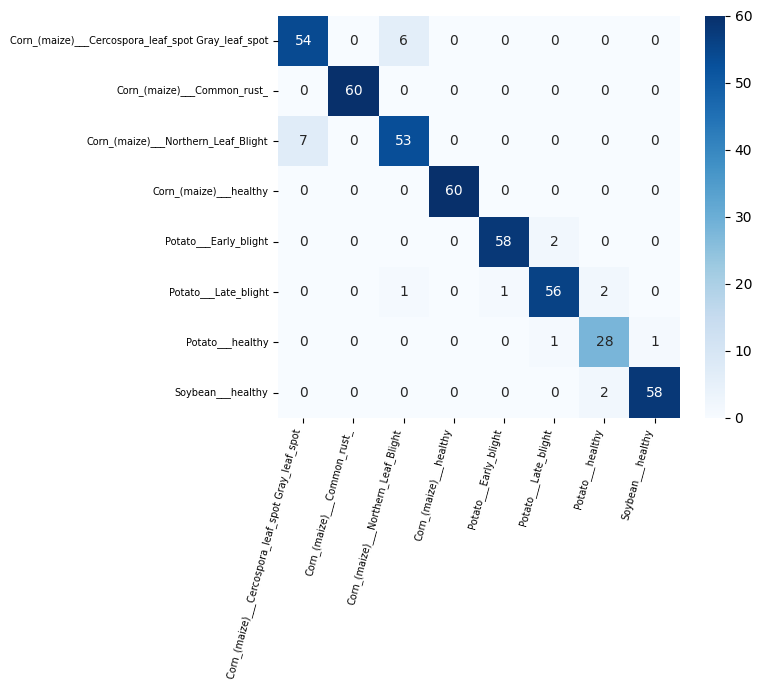

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

metrics = {}

def evaluate(model, X, y, classes, name):
    preds = model.predict(X)
    acc = accuracy_score(y, preds); f1 = f1_score(y, preds, average="macro")
    print(f"\n{name}: accuracy={acc:.3f}  macro-F1={f1:.3f}")
    print(classification_report(y, preds, target_names=classes, zero_division=0))
    return {"accuracy": float(acc), "macro_f1": float(f1)}, preds

metrics["xgboost"], xgb_preds = evaluate(xgb_model, Xva, yva, classes, "XGBoost")
metrics["random_forest"], rf_preds = evaluate(rf, Xva, yva, classes, "RandomForest")

def evaluate_keras_model(model, ds, name):
    y_true, y_pred = [], []
    for xb, yb in ds:
        preds = model.predict(xb, verbose=0)
        y_true.extend(yb.numpy().tolist()); y_pred.extend(np.argmax(preds, axis=1).tolist())
    acc = accuracy_score(y_true, y_pred); f1 = f1_score(y_true, y_pred, average="macro")
    print(f"{name}: accuracy={acc:.3f} macro-F1={f1:.3f}")
    return {"accuracy": float(acc), "macro_f1": float(f1)}

metrics["mobilenetv2"] = evaluate_keras_model(mobilenet_model, val_ds, "MobileNetV2")
metrics["efficientnetb0"] = evaluate_keras_model(efficientnet_model, val_ds, "EfficientNetB0")

print("\n=== Model comparison (macro-F1 decides the winner) ===")
for k, v in sorted(metrics.items(), key=lambda kv: -kv[1]["macro_f1"]):
    print(f"{k:<18} acc={v['accuracy']:.3f}  macro-F1={v['macro_f1']:.3f}")
best_model_name = max(metrics, key=lambda k: metrics[k]["macro_f1"])
print(f"\nBEST MODEL: {best_model_name}")

cm = confusion_matrix(yva, xgb_preds)
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes, ax=ax)
plt.xticks(rotation=75, ha="right", fontsize=7); plt.yticks(fontsize=7)
plt.tight_layout(); plt.savefig(f"{OUT_FIG}/disease_confusion_matrix.png", dpi=150); plt.show()


## Step 12 — Explainability: SHAP + occlusion saliency (tree branch)

Generated regardless of which model wins, since it documents the classical-CV branch's behavior.


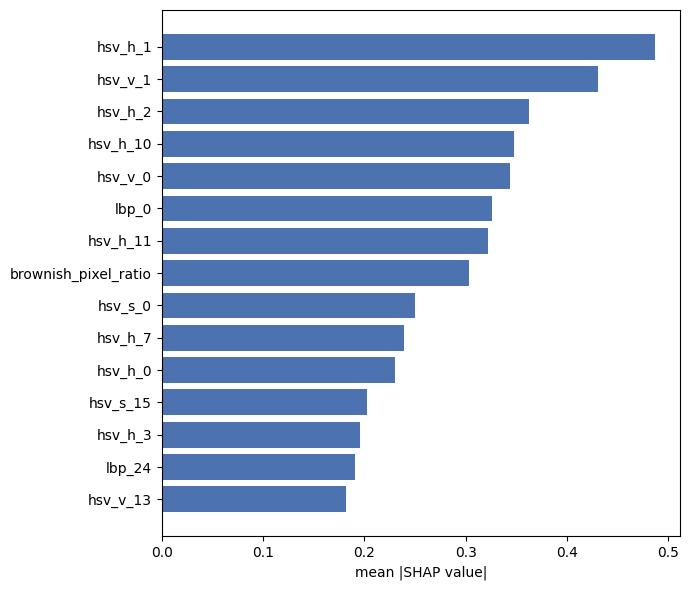

Top 5 features: [('hsv_h_1', 0.4870453476905823), ('hsv_v_1', 0.43023404479026794), ('hsv_h_2', 0.36246466636657715), ('hsv_h_10', 0.34714120626449585), ('hsv_v_0', 0.3434842824935913)]


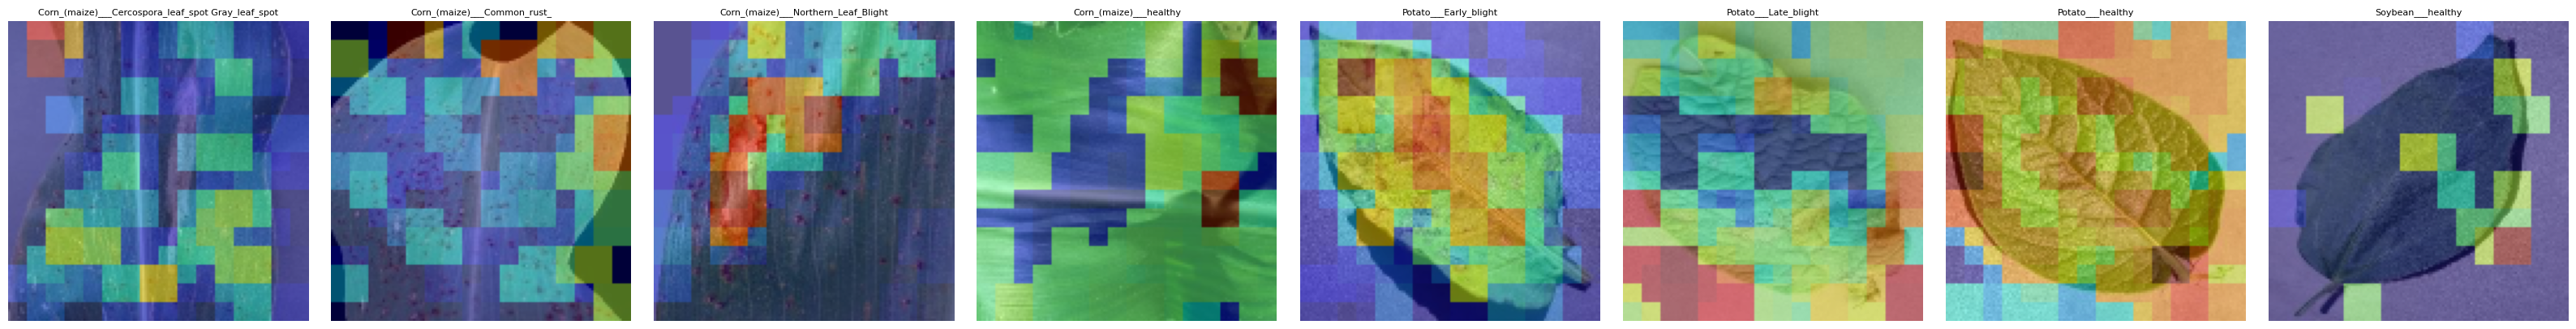

In [ ]:
import shap

def shap_global_importance(model, Xva, path, top_n=15):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(Xva)
    if isinstance(shap_values, list):
        mean_abs = np.mean([np.abs(sv) for sv in shap_values], axis=(0, 1))
    else:
        mean_abs = np.mean(np.abs(shap_values), axis=(0, 2)) if shap_values.ndim == 3 else np.mean(np.abs(shap_values), axis=0)
    order = np.argsort(mean_abs)[::-1][:top_n]
    top_feats = [FEATURE_NAMES[i] for i in order]; top_vals = mean_abs[order]
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.barh(top_feats[::-1], top_vals[::-1], color="#4c72b0")
    ax.set_xlabel("mean |SHAP value|")
    plt.tight_layout(); plt.savefig(path, dpi=150); plt.show()
    return list(zip(top_feats, top_vals.tolist()))

top_feats = shap_global_importance(xgb_model, Xva, f"{OUT_FIG}/disease_shap_feature_importance.png")
print("Top 5 features:", top_feats[:5])

def occlusion_saliency(model, classes, sample_paths_by_class, patch=16, stride=8,
                        out_path=f"{OUT_FIG}/disease_occlusion_saliency.png"):
    n = len(classes)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1: axes = [axes]
    for ci, cls in enumerate(classes):
        fp = sample_paths_by_class[cls]
        img = cv2.resize(cv2.imread(fp), (IMG_SIZE, IMG_SIZE))
        base_prob = model.predict_proba(extract_features(img).reshape(1, -1))[0, ci]
        heat = np.zeros((IMG_SIZE, IMG_SIZE))
        for y0 in range(0, IMG_SIZE - patch + 1, stride):
            for x0 in range(0, IMG_SIZE - patch + 1, stride):
                occ = img.copy(); occ[y0:y0 + patch, x0:x0 + patch] = 127
                prob = model.predict_proba(extract_features(occ).reshape(1, -1))[0, ci]
                heat[y0:y0 + patch, x0:x0 + patch] = np.maximum(heat[y0:y0 + patch, x0:x0 + patch], max(0.0, base_prob - prob))
        axes[ci].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); axes[ci].imshow(heat, cmap="jet", alpha=0.45)
        axes[ci].set_title(cls, fontsize=8); axes[ci].axis("off")
    plt.tight_layout(); plt.savefig(out_path, dpi=150); plt.show()

sample_paths_by_class = {}
for cls in classes:
    for pth in val_paths:
        if f"{os.sep}{cls}{os.sep}" in pth:
            sample_paths_by_class[cls] = pth
            break

occlusion_saliency(xgb_model, classes, sample_paths_by_class)


## Step 13 — Grad-CAM (only meaningful if a CNN won)

Manually replays the head layers after the frozen base, inside one `GradientTape`, instead of
reconstructing a `Model(...)` from the outer graph — this avoids a Keras 3 nested-functional-model
graph-tracing bug that breaks the naive approach.


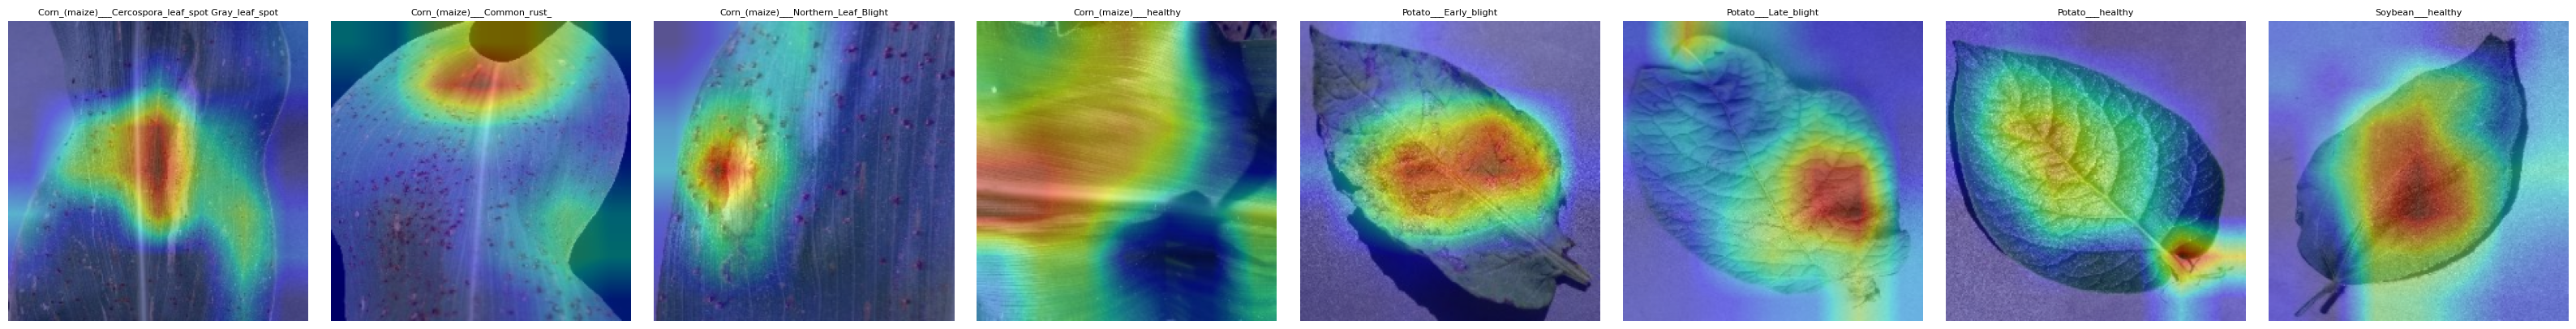

Real Grad-CAM generated for the winning CNN.


In [ ]:
def make_gradcam_heatmap(img_array, cnn_model, base_model, preprocess_fn):
    base_idx = [i for i, l in enumerate(cnn_model.layers) if l is base_model][0]
    head_layers = cnn_model.layers[base_idx + 1:]
    img_processed = preprocess_fn(tf.cast(img_array, tf.float32))
    with tf.GradientTape() as tape:
        conv_outputs = base_model(img_processed, training=False)
        tape.watch(conv_outputs)
        x = conv_outputs
        for layer in head_layers:
            x = layer(x)
        predictions = x
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

if best_model_name == "mobilenetv2":
    cnn_model, cnn_base, preprocess_fn = mobilenet_model, mobilenet_base, mnv2_preprocess
elif best_model_name == "efficientnetb0":
    cnn_model, cnn_base, preprocess_fn = efficientnet_model, efficientnet_base, effnet_preprocess
else:
    cnn_model = None

if cnn_model is not None:
    fig, axes = plt.subplots(1, len(classes), figsize=(4 * len(classes), 4))
    for ci, cls in enumerate(classes):
        fp = sample_paths_by_class[cls]
        img = cv2.cvtColor(cv2.resize(cv2.imread(fp), (IMG_SIZE_CNN, IMG_SIZE_CNN)), cv2.COLOR_BGR2RGB)
        img_array = np.expand_dims(img.astype(np.float32), axis=0)
        heatmap = cv2.resize(make_gradcam_heatmap(img_array, cnn_model, cnn_base, preprocess_fn),
                              (IMG_SIZE_CNN, IMG_SIZE_CNN))
        axes[ci].imshow(img); axes[ci].imshow(heatmap, cmap="jet", alpha=0.45)
        axes[ci].set_title(cls, fontsize=8); axes[ci].axis("off")
    plt.tight_layout(); plt.savefig(f"{OUT_FIG}/disease_gradcam.png", dpi=150); plt.show()
    print("Real Grad-CAM generated for the winning CNN.")
else:
    print("A tree model won -- SHAP + occlusion saliency above are the explainability output.")


## Step 14 — Severity scoring + final save

Uses `predict_proba` / softmax output from the winning model, **never** the ground-truth label.
Uses `VAL_FILE_PATHS` captured back in Step 7, since `.prefetch()` strips `.file_paths` from `val_ds`.


In [ ]:
import pandas as pd
import json
import joblib

SEVERITY_MAP_DEFAULTS = {
    "healthy": 0.0, "early_blight": 0.3, "late_blight": 0.6,
    "common_rust": 0.35, "northern_leaf_blight": 0.5,
    "gray_leaf_spot": 0.45, "cercospora_leaf_spot_gray_leaf_spot": 0.45,
}

def build_severity_vector(classes):
    vec = np.full(len(classes), 0.5, dtype=np.float32)
    unresolved = []
    for i, cls in enumerate(classes):
        key = cls.lower().split("___")[-1].replace(" ", "_").replace(",", "")
        matched = False
        for k, v in SEVERITY_MAP_DEFAULTS.items():
            if k in key:
                vec[i] = v; matched = True; break
        if not matched:
            unresolved.append(cls)
    if unresolved:
        print(f"WARNING: fell back to default severity 0.5 for: {unresolved}")
    return vec

severity_vec = build_severity_vector(classes)

if best_model_name in ("mobilenetv2", "efficientnetb0"):
    cnn_final = mobilenet_model if best_model_name == "mobilenetv2" else efficientnet_model
    final_val_paths = VAL_FILE_PATHS
    proba_best, true_idx = [], []
    for xb, yb in val_ds:
        proba_best.append(cnn_final.predict(xb, verbose=0))
        true_idx.extend(yb.numpy().tolist())
    proba_best = np.concatenate(proba_best)
else:
    final_val_paths = val_paths
    true_idx = yva
    proba_best = xgb_model.predict_proba(Xva) if best_model_name == "xgboost" else rf.predict_proba(Xva)

pred_severity_best = proba_best @ severity_vec
pred_class_idx_best = np.argmax(proba_best, axis=1)

pred_df = pd.DataFrame({
    "image_path": final_val_paths,
    "true_class": [classes[i] for i in true_idx],
    "predicted_class": [classes[i] for i in pred_class_idx_best],
    "predicted_severity": pred_severity_best,
})
pred_df.to_csv(f"{OUT_MET}/disease_val_predictions.csv", index=False)

joblib.dump(xgb_model, f"{ART}/disease_model.joblib")
joblib.dump({"classes": classes, "feature_names": FEATURE_NAMES,
             "severity_vec": severity_vec.tolist(), "img_size": IMG_SIZE,
             "best_model": best_model_name}, f"{ART}/disease_meta.joblib")

with open(f"{OUT_MET}/disease_model_metrics.json", "w") as f:
    json.dump({**metrics, "best_model": best_model_name}, f, indent=2)

print(f"DONE. Best model: {best_model_name}")
print(pred_df.head())


DONE. Best model: efficientnetb0
                                          image_path  \
0  data/images/val/Corn_(maize)___Cercospora_leaf...   
1  data/images/val/Corn_(maize)___Cercospora_leaf...   
2  data/images/val/Corn_(maize)___Cercospora_leaf...   
3  data/images/val/Corn_(maize)___Cercospora_leaf...   
4  data/images/val/Corn_(maize)___Cercospora_leaf...   

                                          true_class  \
0  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...   
1  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...   
2  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...   
3  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...   
4  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...   

                                     predicted_class  predicted_severity  
0                Corn_(maize)___Northern_Leaf_Blight            0.448863  
1  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...            0.437561  
2  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...            0.39

In [ ]:
# Save the actual winning model,
if best_model_name == "mobilenetv2":
    mobilenet_model.save(f"{ART}/best_disease_model.keras")
    print("Saved MobileNetV2 as best_disease_model.keras")
elif best_model_name == "efficientnetb0":
    efficientnet_model.save(f"{ART}/best_disease_model.keras")
    print("Saved EfficientNetB0 as best_disease_model.keras")
else:
    # if a tree model won, save that instead under the same standardized name
    winning_tree_model = xgb_model if best_model_name == "xgboost" else rf
    joblib.dump(winning_tree_model, f"{ART}/best_disease_model.joblib")
    print(f"Tree model won ({best_model_name}) — saved as best_disease_model.joblib instead")

Saved EfficientNetB0 as best_disease_model.keras


In [ ]:
!zip -rq disease_detection_part.zip artifacts_disease outputs -x "*.DS_Store"
from google.colab import files
files.download("disease_detection_part.zip")
print("Zip ready for download: disease_detection_part.zip")

try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    import os
    os.makedirs('/content/drive/MyDrive/agrivision', exist_ok=True)
    !cp disease_detection_part.zip /content/drive/MyDrive/agrivision/
    print("Also backed up to Google Drive.")
except Exception as e:
    print("Drive backup skipped (not required) -- reason:", e)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Zip ready for download: disease_detection_part.zip
Mounted at /content/drive
Also backed up to Google Drive.


#  Crop Disease Detection using Deep Learning

## Project Overview

This notebook develops an AI-based crop disease detection system that identifies diseases from crop leaf images. Given a leaf photograph, the model predicts the disease class (or healthy condition), generates an explainable visual heatmap showing the regions responsible for the prediction, and computes a **severity score** between **0 (healthy)** and **1 (very severe)**. This severity score is later used by a separate crop yield prediction model to estimate crop yield loss.

## Why Multiple Models?

Rather than selecting a single model beforehand, this notebook trains and compares four different models:

- XGBoost
- Random Forest
- MobileNetV2
- EfficientNetB0

XGBoost and Random Forest serve as machine learning baselines, while MobileNetV2 and EfficientNetB0 are transfer learning models for image classification. The model with the best validation performance is automatically selected.

## Explainable AI

To improve transparency and trust, Grad-CAM visualizations are generated for deep learning models. These heatmaps highlight the regions of the leaf that contributed most to the prediction, helping verify that the model focuses on actual disease symptoms.

## Outputs

The notebook produces:

- Best-performing trained model
- Accuracy, Precision, Recall, and F1-score
- Confusion Matrix
- Grad-CAM visualizations
- Disease severity score (0–1) for each validation image

The severity score is later combined with weather and soil features in the crop yield prediction module.

---

# Dataset

This project uses the **PlantVillage** dataset, a widely used public benchmark dataset for plant disease classification.

Only three crops are included:

- Potato
- Corn (Maize)
- Soybean

The dataset contains **8 disease/healthy classes** with:

- **1,802 training images**
- **450 validation images**

The validation set consists of images that were never used during training, ensuring a fair evaluation of model performance.